# Download CKA Library

In [1]:
!pip install torch-cka

In [1]:
#prepares the environment and decides whether computation will run on CPU
import torch
from robustbench import load_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/robustbench/loaders.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Device: cuda


In [2]:
#load two RobustBench models
model_a = load_model(
    model_name="Standard",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_b = load_model(
    model_name="Engstrom2019Robustness",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_c = load_model(
    model_name="Pang2022Robustness_WRN28_10",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_a.eval()
model_b.eval()
model_c.eval()

print(type(model_a))
print(type(model_b))

<class 'robustbench.model_zoo.architectures.wide_resnet.WideResNet'>
<class 'robustbench.model_zoo.cifar10.Engstrom2019RobustnessNet'>


In [3]:
#test that both models run correctly
x = torch.randn(1, 3, 32, 32).to(device)

with torch.no_grad():
    y_a = model_a(x)
    y_b = model_b(x)
    y_c = model_c(x)

print("Model A output shape:", y_a.shape)
print("Model B output shape:", y_b.shape)
print("Model B output shape:", y_c.shape)

Model A output shape: torch.Size([1, 10])
Model B output shape: torch.Size([1, 10])
Model B output shape: torch.Size([1, 10])


In [4]:
#load real CIFAR-10 test data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print("Test set loaded:", len(test_dataset))

Test set loaded: 10000


In [5]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])
Labels: tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9,
        5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9,
        7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3], device='cuda:0')


In [6]:
#compare predictions of the two models
with torch.no_grad():
    out_a = model_a(images)
    out_b = model_b(images)
    out_c = model_c(images)

print("Model A output shape:", out_a.shape)
print("Model B output shape:", out_b.shape)
print("Model C output shape:", out_c.shape)


Model A output shape: torch.Size([64, 10])
Model B output shape: torch.Size([64, 10])
Model C output shape: torch.Size([64, 10])


In [7]:
#compare predictions of the two models
pred_a = out_a.argmax(dim=1)
pred_b = out_b.argmax(dim=1)

print("True labels: ", labels.cpu().tolist())
print("Pred A:      ", pred_a.cpu().tolist())
print("Pred B:      ", pred_b.cpu().tolist())

True labels:  [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3]
Pred A:       [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 6, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 9, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 5, 3, 8, 8, 7, 7, 4, 3, 7, 5, 6, 3]
Pred B:       [3, 8, 8, 0, 6, 6, 1, 6, 3, 9, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 0, 9, 4, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 7, 9, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 7, 6, 7, 3, 6, 9]


In [8]:
#Count how many predictions each model got correct in this batch
correct_a = (pred_a == labels).sum().item()
correct_b = (pred_b == labels).sum().item()

print(f"Model A correct: {correct_a}/{labels.size(0)}")
print(f"Model B correct: {correct_b}/{labels.size(0)}")

Model A correct: 59/64
Model B correct: 57/64


In [9]:
#converts numeric class IDs into human-readable CIFAR-10 names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

for i in range(len(labels)):
    print(f"Image {i}: true={classes[labels[i].item()]}, "
          f"model_a={classes[pred_a[i].item()]}, "
          f"model_b={classes[pred_b[i].item()]}")

Image 0: true=cat, model_a=cat, model_b=cat
Image 1: true=ship, model_a=ship, model_b=ship
Image 2: true=ship, model_a=ship, model_b=ship
Image 3: true=airplane, model_a=airplane, model_b=airplane
Image 4: true=frog, model_a=frog, model_b=frog
Image 5: true=frog, model_a=frog, model_b=frog
Image 6: true=automobile, model_a=automobile, model_b=automobile
Image 7: true=frog, model_a=frog, model_b=frog
Image 8: true=cat, model_a=cat, model_b=cat
Image 9: true=automobile, model_a=automobile, model_b=truck
Image 10: true=airplane, model_a=airplane, model_b=airplane
Image 11: true=truck, model_a=truck, model_b=truck
Image 12: true=dog, model_a=dog, model_b=dog
Image 13: true=horse, model_a=horse, model_b=horse
Image 14: true=truck, model_a=truck, model_b=truck
Image 15: true=ship, model_a=frog, model_b=ship
Image 16: true=dog, model_a=dog, model_b=dog
Image 17: true=horse, model_a=horse, model_b=horse
Image 18: true=ship, model_a=ship, model_b=ship
Image 19: true=frog, model_a=frog, model_b=

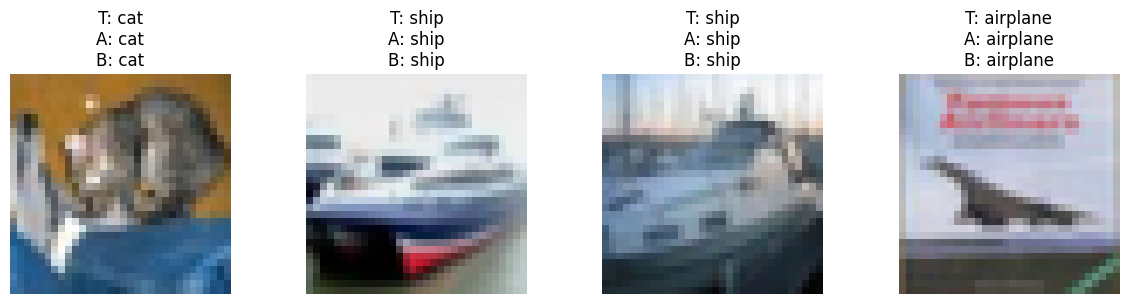

In [10]:
#Show a few images from the batch
import matplotlib.pyplot as plt

num_show = 4
fig, axes = plt.subplots(1, num_show, figsize=(12, 3))

for i in range(num_show):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(
        f"T: {classes[labels[i].item()]}\n"
        f"A: {classes[pred_a[i].item()]}\n"
        f"B: {classes[pred_b[i].item()]}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
#Measure clean accuracy on a few batches instead of just one
num_batches = 20
total = 0
correct_a = 0
correct_b = 0

with torch.no_grad():
    for batch_idx, (imgs, lbls) in enumerate(test_loader):
        if batch_idx >= num_batches:
            break

        imgs = imgs.to(device)
        lbls = lbls.to(device)

        out_a = model_a(imgs)
        out_b = model_b(imgs)

        pred_a = out_a.argmax(dim=1)
        pred_b = out_b.argmax(dim=1)

        correct_a += (pred_a == lbls).sum().item()
        correct_b += (pred_b == lbls).sum().item()
        total += lbls.size(0)

print(f"Model A clean accuracy on {total} images: {correct_a/total:.4f}")
print(f"Model B clean accuracy on {total} images: {correct_b/total:.4f}")

Model A clean accuracy on 1280 images: 0.9445
Model B clean accuracy on 1280 images: 0.8797


In [12]:
#Save one clean batch for later adversarial experiments
clean_images = images.clone().detach()
clean_labels = labels.clone().detach()

print("Saved clean batch:", clean_images.shape, clean_labels.shape)

Saved clean batch: torch.Size([64, 3, 32, 32]) torch.Size([64])


In [13]:
from autoattack import AutoAttack

attacker_a = AutoAttack(
    model_a,
    norm='Linf',
    eps=8/255,
    version='standard',
    device=device
)

attacker_b = AutoAttack(
    model_b,
    norm='Linf',
    eps=8/255,
    version='standard',
    device=device
)

attacker_c = AutoAttack(
    model_c,
    norm='Linf',
    eps=8/255,
    version='standard',
    device=device
)

print("AutoAttack ready")

setting parameters for standard version
setting parameters for standard version
setting parameters for standard version
AutoAttack ready


In [14]:
#Run AutoAttack on the clean batch for model_a
adv_images_a = attacker_a.run_standard_evaluation(
    clean_images,
    clean_labels,
    bs=64
)

adv_images_b = attacker_b.run_standard_evaluation(
    clean_images,
    clean_labels,
    bs=64
)

adv_images_c = attacker_c.run_standard_evaluation(
    clean_images,
    clean_labels,
    bs=64
)

using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 92.19%
apgd-ce - 1/1 - 59 out of 59 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 12.3 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 89.06%
apgd-ce - 1/1 - 28 out of 57 successfully perturbed
robust accuracy after APGD-CE: 45.31% (total time 5.6 s)
apgd-t - 1/1 - 1 out of 29 successfully perturbed
robust accuracy after APGD-T: 43.75% (total time 35.2 s)
fab-t - 1/1 - 0 out of 28 successfully perturbed
robust accuracy after FAB-T: 43.75% (total time 95.3 s)
square - 1/1 - 0 out of 28 successfully perturbed
robust accuracy after SQUARE: 43.75% (total time 174.3 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 43.75%
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy

In [15]:
#Evaluate model_a on the adversarial examples
with torch.no_grad():
    adv_out_a = model_a(adv_images_a)

adv_pred_a = adv_out_a.argmax(dim=1)
print("Model A test:")
print("True labels: ", clean_labels.cpu().tolist())
print("Adv pred A:  ", adv_pred_a.cpu().tolist())

acc_a = (adv_pred_a == clean_labels).sum().item()
print(f"Model A accuracy on adversarial examples: {acc_a}/{clean_labels.size(0)}")

with torch.no_grad():
    adv_out_b = model_b(adv_images_b)

adv_pred_b = adv_out_b.argmax(dim=1)
print("\nModel B test:")
print("True labels: ", clean_labels.cpu().tolist())
print("Adv pred B:  ", adv_pred_b.cpu().tolist())

acc_b = (adv_pred_b == clean_labels).sum().item()
print(f"Model B accuracy on adversarial examples: {acc_b}/{clean_labels.size(0)}")

with torch.no_grad():
    adv_out_c = model_c(adv_images_c)

adv_pred_c = adv_out_c.argmax(dim=1)
print("\nModel C test:")
print("True labels: ", clean_labels.cpu().tolist())
print("Adv pred C:  ", adv_pred_c.cpu().tolist())

acc_c = (adv_pred_c == clean_labels).sum().item()
print(f"Model C accuracy on adversarial examples: {acc_c}/{clean_labels.size(0)}")

Model A test:
True labels:  [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3]
Adv pred A:   [6, 1, 6, 8, 1, 3, 3, 3, 6, 6, 3, 2, 3, 5, 8, 6, 7, 3, 6, 2, 2, 3, 3, 0, 4, 3, 6, 6, 1, 2, 3, 2, 2, 2, 2, 8, 5, 9, 3, 3, 2, 3, 3, 3, 2, 1, 6, 6, 5, 2, 6, 6, 5, 6, 2, 2, 2, 3, 3, 3, 5, 5, 2, 9]
Model A accuracy on adversarial examples: 0/64

Model B test:
True labels:  [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9, 7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3]
Adv pred B:   [5, 8, 1, 0, 4, 6, 3, 4, 4, 9, 5, 9, 6, 7, 9, 8, 7, 7, 0, 6, 1, 0, 0, 9, 4, 2, 3, 0, 9, 6, 4, 2, 7, 3, 9, 8, 7, 9, 9, 5, 4, 6, 5, 5, 0, 9, 2, 3, 4, 4, 9, 6, 2, 6, 8, 8, 4, 6, 7, 3, 7, 6, 6, 9]
Model B accuracy on adversarial examples: 28/64

Model C test:
True labels:  [3, 8, 8, 0, 6, 6, 

# Transferability Matrix
The transferability matrix is an nxn matrix, where it calculates the accuracy of model_i on the examples created by model_j.
The diagonals of the matrix are a model tested on its own examples generated so they will match the test in the cell above.



In [81]:
import numpy as np
def get_transferability_matrix(models, model_adv_images, adv_true_labels):
    """
    row = i, column = j
    t_matrix[i][j] = model[i] prediction accuracy on model[j] adv_images 

    * adv_images[i] = adv_images generated for model[i]
    * true_label[i] = true label of adv_image[i]
 
    models: list of models to create transferability matrix for
    adv_images: list of adversarial images generated for models in models list
    true_labels: list of true labels for the images 
    """
    num_models = len(models)
    t_matrix = np.empty(shape=(num_models, num_models))

    for i in range(num_models):
        # 
        pred_model = models[i]
        for j in range(num_models):
            # copying the evaluation method in the previous cell
            adv_images = model_adv_images[j]
            true_labels = adv_true_labels[j]
            with torch.no_grad():
                print(f'calculating -> ({i}, {j})')
                adv_out_i = pred_model(adv_images)

            adv_pred_i = adv_out_i.argmax(dim=1)
            acc_i = (adv_pred_i == true_labels).sum().item()
            t_matrix[i][j] = 1 - (acc_i / len(true_labels))
    return t_matrix


In [ ]:
# testing get_transferability_matrix fuction, the diagonal should match the model_a test 
models = [model_a, model_b, model_c]
model_labels = ['Standard', 'Engstrom2019', 'Pang2022']
# we want to only use the adversarial examples where the models failed
loc_a_fooled, loc_b_fooled, loc_c_fooled = adv_pred_a != clean_labels, adv_pred_b != clean_labels, adv_pred_c != clean_labels
a_fooled, a_fooled_labels = adv_images_a[loc_a_fooled], clean_labels[loc_a_fooled]
b_fooled, b_fooled_labels = adv_images_b[loc_b_fooled], clean_labels[loc_b_fooled]
c_fooled, c_fooled_labels = adv_images_c[loc_c_fooled], clean_labels[loc_c_fooled]

adv_images = [a_fooled, b_fooled, c_fooled]
true_labels = [a_fooled_labels, b_fooled_labels, c_fooled_labels]

t_matrix = get_transferability_matrix(models=models, model_adv_images=adv_images, adv_true_labels=true_labels)
full_t_matrix = get_transferability_matrix(models=models, model_adv_images=[adv_images_a, adv_images_b, adv_images_c], fooled_true_labels=[clean_labels, clean_labels, clean_labels])
t_matrix

calculating -> (0, 0)
calculating -> (0, 1)
calculating -> (0, 2)
calculating -> (1, 0)
calculating -> (1, 1)
calculating -> (1, 2)
calculating -> (2, 0)
calculating -> (2, 1)
calculating -> (2, 2)


array([[1.        , 0.36111111, 0.46153846],
       [0.09375   , 1.        , 0.88461538],
       [0.125     , 0.41666667, 1.        ]])

In [ ]:
a_not_fooled = adv_pred_a != clean_labels
adv_images_a[a_not_fooled] - clean_images[a_not_fooled]

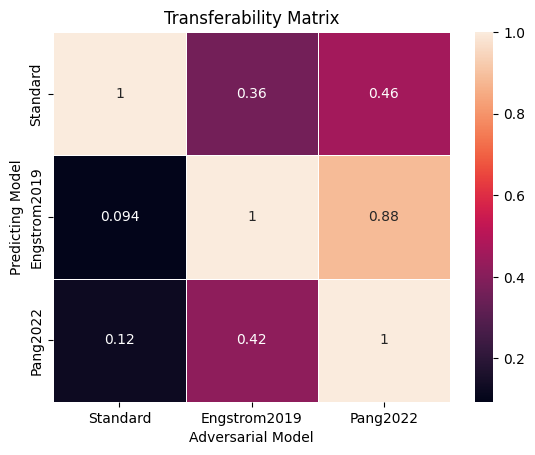

In [87]:
import seaborn as sns
import matplotlib.pylab as plt
import pandas as pd

dataframe = pd.DataFrame(t_matrix, index=model_labels, columns=model_labels)

ax = sns.heatmap(dataframe, xticklabels=model_labels, yticklabels=model_labels, linewidths=0.5, annot=True)
ax.set(xlabel='Adversarial Model', ylabel='Predicting Model', title='Transferability Matrix')
plt.show()

# CKA Testing starts here:

In [67]:
# First lets get a list of layer names so we don't have a million layer evaluations
model_a_layer_names = ['conv1', 'block1', 'block2', 'block3']
model_c_layer_names = ['init_conv', 'layer.0', 'layer.1', 'layer.2']
model_a_layer_desc = ['conv1', 'layer1', 'layer2', 'layer3']
model_c_layer_desc = ['conv1', 'layer1', 'layer2', 'layer3']

In [54]:
model_a

WideResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (block1): NetworkBlock(
    (layer): Sequential(
      (0): BasicBlock(
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(16, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (convShortcut): Conv2d(16, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): BasicBlock(
        (bn1): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNor

In [66]:
model_c


DMWideResNet(
  (init_conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (layer): Sequential(
    (0): _BlockGroup(
      (block): Sequential(
        (0): _Block(
          (batchnorm_0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu_0): Swish()
          (conv_0): Conv2d(16, 160, kernel_size=(3, 3), stride=(1, 1), bias=False)
          (batchnorm_1): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu_1): Swish()
          (conv_1): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (shortcut): Conv2d(16, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (1): _Block(
          (batchnorm_0): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu_0): Swish()
          (conv_0): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), bias=False)
          (batchn

In [68]:
from torch_cka import CKA

cka = CKA(model_a, model_c,
          model1_name="Model A",   # good idea to provide names to avoid confusion
          model2_name="Model C",   
          model1_layers=model_a_layer_names, # List of layers to extract features from
          model2_layers=model_c_layer_names, # extracts all layer features by default
          device='cuda')

# test loader is the loader created at the start of this notebook
cka.compare(test_loader)

/home/kwest/um/S2P/MRP-Sem_2-Group_8/.venv/lib/python3.10/site-packages/torch_cka/cka.py:145: UserWarning: Dataloader for Model 2 is not given. Using the same dataloader for both models.
  warn("Dataloader for Model 2 is not given. Using the same dataloader for both models.")
| Comparing features |: 100%|██████████| 157/157 [00:39<00:00,  3.98it/s]


In [69]:
# look at results? see what's goin on
results = cka.export()

results

{'model1_name': 'Model A',
 'model2_name': 'Model C',
 'CKA': tensor([[0.9217, 0.9151, 0.7605, 0.3265],
         [0.4293, 0.5348, 0.5721, 0.3309],
         [0.2437, 0.3449, 0.5519, 0.4327],
         [0.0999, 0.1353, 0.2218, 0.5892]]),
 'model1_layers': ['conv1', 'block1', 'block2', 'block3'],
 'model2_layers': ['init_conv', 'layer.0', 'layer.1', 'layer.2'],
 'dataset1_name': 'Dataset CIFAR10',
 'dataset2_name': 'Dataset CIFAR10'}

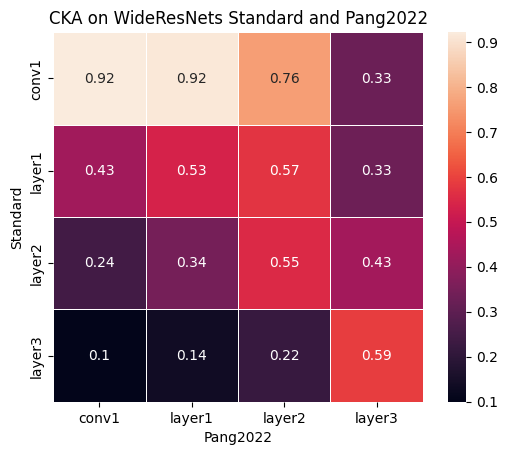

In [72]:
import seaborn as sns
import matplotlib.pylab as plt

ax = sns.heatmap(results['CKA'], xticklabels=model_c_layer_desc, yticklabels=model_a_layer_desc, linewidths=0.5, annot=True, square=True)
ax.set(xlabel='Pang2022', ylabel='Standard', title='CKA on WideResNets Standard and Pang2022')
plt.show()